# GCN+TCN diagnostics — embedding influence on product 26008

Analisa o impacto da componente GCN (e do threshold do grafo Spearman) para o produto **26008**, a partir dos CSVs gerados pelo grid runner em `main_gcn_tcn.py`.

**Inputs esperados** (mesma pasta deste notebook):
- `diagnostics.csv` — uma linha por época para cada `(produto, seed, threshold, config)` da corrida baseline (`ABLATE_Z=False`).
- `diagnostics_ablation.csv` — mesma estrutura mas com `ABLATE_Z=True` (z zerado).
- `spearman.csv` — uma linha por experiência com as métricas finais (RMSE, MAE, …).

**Checklist de diagnóstico**:
1. **Topologia** muda com o threshold? (`num_edges_mean` por threshold)
2. **Convergência** do treino — quantas épocas até `val_loss` estagnar?
3. **GCN viva ou morta?** `‖z‖`, `Var(z)` e `‖∇gcn‖/‖∇tcn‖` ao longo das épocas.
4. **O threshold importa?** Final RMSE vs threshold (média ± std sobre seeds).
5. **A GCN contribui?** Comparação baseline vs ablation no `spearman.csv`.
6. **Curvas de embedding** — overlay `val_loss` baseline vs ablation por época (resposta directa à pergunta "o embedding melhora 26008?").


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Configuration ────────────────────────────────────────────────────────
SCRIPT_DIR   = os.path.dirname(os.path.abspath("__file__")) if "__file__" in globals() else os.getcwd()
DIAG_PATH    = os.path.join(SCRIPT_DIR, "diagnostics.csv")
ABLAT_PATH   = os.path.join(SCRIPT_DIR, "diagnostics_ablation.csv")
RESULTS_PATH = os.path.join(SCRIPT_DIR, "spearman.csv")

# Choose which product to analyse
PRODUCT_ID = 26008      # change to whichever item is in diagnostics.csv
METRIC     = "spearman"

print("Reading from:", SCRIPT_DIR)
print("diagnostics.csv :", os.path.exists(DIAG_PATH))
print("ablation csv    :", os.path.exists(ABLAT_PATH))
print("results csv     :", os.path.exists(RESULTS_PATH))


Reading from: c:\Users\andre.silva\OneDrive - Retail Consult\Desktop\Dissertation25-26\GNN\DynamicSimilarities\GCN_TCN
diagnostics.csv : True
ablation csv    : True
results csv     : True


In [2]:
diag = pd.read_csv(DIAG_PATH)
diag = diag[(diag["product_id"] == PRODUCT_ID) & (diag["metric"] == METRIC)].copy()
diag["threshold"] = pd.to_numeric(diag["threshold"], errors="coerce")

print(f"Rows for product {PRODUCT_ID}: {len(diag)}")
print("Seeds      :", sorted(diag["seed"].unique()))
print("Thresholds :", sorted(diag["threshold"].dropna().unique()))
print("Max epoch  :", int(diag["epoch"].max()))
diag.head()


Rows for product 26008: 903
Seeds      : [np.int64(42)]
Thresholds : [np.float64(0.7), np.float64(0.75), np.float64(0.82), np.float64(0.85), np.float64(0.88), np.float64(0.91)]
Max epoch  : 180


,product_id,store_id,seed,metric,window_size,step_size,threshold,percentile,enable_edges,enable_second_degree,ablate_z,num_edges_mean,epoch,train_loss,val_loss,z_norm_mean,z_var_mean,grad_norm_gcn,grad_norm_tcn,grad_ratio_gcn_tcn
0,26008,6269,42,spearman,15,1,0.7,NaN,True,False,False,325.841758,1,0.092373,0.014228,3.960759,0.011627,0.752047,2.365078,0.317980
1,26008,6269,42,spearman,15,1,0.7,NaN,True,False,False,325.841758,2,0.023213,0.010375,3.984679,0.014765,0.309150,1.007249,0.306925
2,26008,6269,42,spearman,15,1,0.7,NaN,True,False,False,325.841758,3,0.020535,0.004095,3.984520,0.014154,0.283093,0.938049,0.301789
3,26008,6269,42,spearman,15,1,0.7,NaN,True,False,False,325.841758,4,0.014481,0.004814,3.983580,0.014958,0.193307,0.645336,0.299545
4,26008,6269,42,spearman,15,1,0.7,NaN,True,False,False,325.841758,5,0.012535,0.004837,3.983676,0.015037,0.162358,0.541915,0.299601


## 1. Topologia — o threshold muda mesmo o grafo?

`num_edges_mean` é constante para cada `(produto, threshold)` (o grafo é construído uma vez). Se os valores de `num_edges_mean` forem semelhantes entre thresholds, o threshold **não está a fazer nada** na vizinhança — e nenhuma análise posterior vai mostrar dependência.


 threshold  num_edges_mean
      0.70      325.841758
      0.75      104.549451
      0.82       13.393407
      0.85        4.604396
      0.88        1.441758
      0.91        0.353846


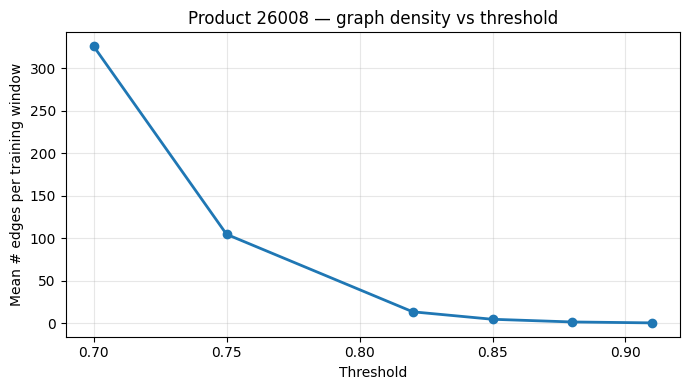

In [3]:
topo = (
    diag.dropna(subset=["threshold"])
        .groupby("threshold")["num_edges_mean"]
        .first()
        .reset_index()
        .sort_values("threshold")
)
print(topo.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(topo["threshold"], topo["num_edges_mean"], marker="o", lw=2)
ax.set_xlabel("Threshold"); ax.set_ylabel("Mean # edges per training window")
ax.set_title(f"Product {PRODUCT_ID} — graph density vs threshold")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 2. Convergência — quando estagna o `val_loss`?

`val_loss` ao longo das épocas, por seed e threshold. Se as curvas plateau-am todas no mesmo valor, o threshold é irrelevante para a optimização. Se algumas curvas atingem mínimos visivelmente menores, há sinal extraível.


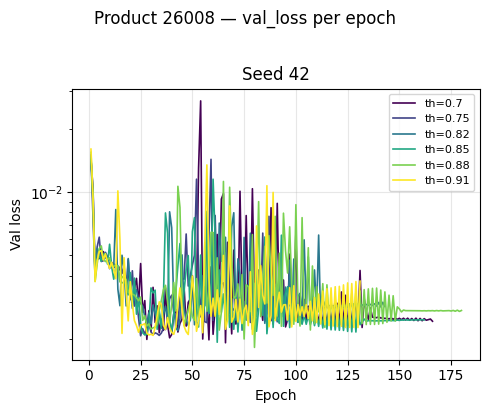

 seed  threshold  best_epoch  best_val_loss
   42       0.70          66       0.001924
   42       0.75          25       0.002076
   42       0.82          43       0.002198
   42       0.85          62       0.001934
   42       0.88          80       0.001829
   42       0.91          31       0.002085


In [4]:
seeds      = sorted(diag["seed"].unique())
thresholds = sorted(diag["threshold"].dropna().unique())
cmap       = plt.get_cmap("viridis")
colors     = {t: cmap(i / max(len(thresholds) - 1, 1)) for i, t in enumerate(thresholds)}

fig, axes = plt.subplots(1, len(seeds), figsize=(5 * len(seeds), 4), sharey=True, squeeze=False)
for ax, seed in zip(axes[0], seeds):
    for t in thresholds:
        sub = diag[(diag["seed"] == seed) & (diag["threshold"] == t)].sort_values("epoch")
        if sub.empty:
            continue
        ax.plot(sub["epoch"], sub["val_loss"], color=colors[t], label=f"th={t}", lw=1.2)
    ax.set_title(f"Seed {seed}")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Val loss"); ax.set_yscale("log")
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.suptitle(f"Product {PRODUCT_ID} — val_loss per epoch", y=1.02)
plt.tight_layout(); plt.show()

# Epoch at which the val_loss minimum was reached (early-stop indicator)
best_epoch = (
    diag.sort_values("val_loss")
        .groupby(["seed", "threshold"], as_index=False)
        .first()[["seed", "threshold", "epoch", "val_loss"]]
        .rename(columns={"epoch": "best_epoch", "val_loss": "best_val_loss"})
        .sort_values(["seed", "threshold"])
)
print(best_epoch.to_string(index=False))


## 3. GCN viva ou morta?

Três sinais por época:
- **`‖z‖_mean`** — norma média do embedding do nó central. Se cair para ~0 ou colapsar para um valor constante → mode collapse da GCN.
- **`Var(z)_mean`** — variância das dimensões de `z` entre amostras. Se ~0, o `z` é o mesmo para qualquer input → bypass total.
- **`‖∇gcn‖ / ‖∇tcn‖`** — razão das normas de gradiente. `< 1e-3` ⇒ ramo praticamente sem actualizações; `~0.1–1` ⇒ ramo activo.


KeyError: 'grad_ratio_gcn_lstm'

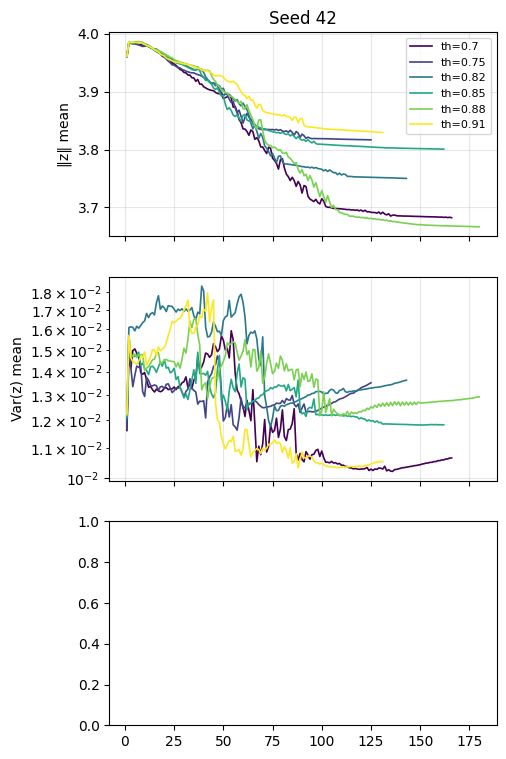

In [5]:
signals = [
    ("z_norm_mean",        "‖z‖ mean",         "linear"),
    ("z_var_mean",         "Var(z) mean",      "log"),
    ("grad_ratio_gcn_tcn", "‖∇gcn‖ / ‖∇tcn‖",  "log"),
]

fig, axes = plt.subplots(len(signals), len(seeds),
                         figsize=(5 * len(seeds), 3 * len(signals)),
                         sharex=True, squeeze=False)

for row, (col_name, ylabel, yscale) in enumerate(signals):
    for j, seed in enumerate(seeds):
        ax = axes[row, j]
        for t in thresholds:
            sub = diag[(diag["seed"] == seed) & (diag["threshold"] == t)].sort_values("epoch")
            if sub.empty:
                continue
            ax.plot(sub["epoch"], sub[col_name], color=colors[t], lw=1.2, label=f"th={t}")
        ax.set_ylabel(ylabel); ax.set_yscale(yscale); ax.grid(alpha=0.3)
        if row == 0:
            ax.set_title(f"Seed {seed}")
        if row == len(signals) - 1:
            ax.set_xlabel("Epoch")
        if row == 0 and j == len(seeds) - 1:
            ax.legend(fontsize=8, loc="best")

# reference lines for grad ratio
for j in range(len(seeds)):
    ax = axes[2, j]
    ax.axhline(1e-3, color="red",    ls="--", lw=0.8, alpha=0.6)
    ax.axhline(1e-1, color="orange", ls="--", lw=0.8, alpha=0.6)

fig.suptitle(f"Product {PRODUCT_ID} — GCN signal health (TCN head)", y=1.01)
plt.tight_layout(); plt.show()

# Final values per (seed, threshold)
final = (
    diag.sort_values("epoch")
        .groupby(["seed", "threshold"], as_index=False)
        .tail(1)[["seed", "threshold", "z_norm_mean", "z_var_mean", "grad_ratio_gcn_tcn"]]
        .sort_values(["seed", "threshold"])
)
print("Final epoch values:")
print(final.to_string(index=False))


## 4. Desempenho final — RMSE/MAE em `spearman.csv` por threshold × seed


In [ ]:
if not os.path.exists(RESULTS_PATH):
    print(f"{RESULTS_PATH} not found — skip section 4.")
else:
    res = pd.read_csv(RESULTS_PATH)
    res = res[res["product_id"] == PRODUCT_ID].copy()
    res["threshold"] = pd.to_numeric(res["threshold"], errors="coerce")

    # Baseline (ablate_z=False) for cleaner comparison; fall back to all if column missing
    if "ablate_z" in res.columns:
        base = res[res["ablate_z"].astype(str).str.lower().isin(["false", "0", "0.0"])]
    else:
        base = res

    metric_col = "rmse" if "rmse" in base.columns else base.columns[-1]
    pivot = base.pivot_table(index="seed", columns="threshold",
                             values=metric_col, aggfunc="mean")
    print(f"{metric_col.upper()} per seed × threshold (baseline):")
    print(pivot.round(4).to_string())

    summary = pivot.agg(["mean", "std"]).T.reset_index()
    print("\nAcross-seed summary:")
    print(summary.round(4).to_string(index=False))

    fig, ax = plt.subplots(figsize=(7, 4))
    for seed in pivot.index:
        ax.plot(pivot.columns, pivot.loc[seed], marker="o", label=f"seed {seed}", alpha=0.7)
    ax.errorbar(summary["threshold"], summary["mean"], yerr=summary["std"],
                color="black", lw=2, capsize=4, label="mean ± std")
    ax.set_xlabel("Threshold"); ax.set_ylabel(metric_col.upper())
    ax.set_title(f"Product {PRODUCT_ID} — {metric_col.upper()} vs threshold")
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()


## 5. Ablation — baseline vs `ablate_z=True` (sem GCN)

Esta secção compara o RMSE do modelo completo com o do modelo em que o `z` da GCN é zerado em forward (TCN ainda recebe target+exog). Se `Δ = ablate − baseline > 0`, a GCN está a contribuir; se `Δ ≤ 0`, a GCN é decorativa ou prejudicial.

Para gerar a coluna `ablate_z=True` em `spearman.csv`, correr `main_gcn_tcn.py` com `ABLATE_Z = True`.


In [ ]:
if not os.path.exists(RESULTS_PATH) or "ablate_z" not in pd.read_csv(RESULTS_PATH, nrows=1).columns:
    print("Sem coluna `ablate_z` em spearman.csv — correr main_gcn_tcn.py com ABLATE_Z=True e voltar a executar.")
else:
    res = pd.read_csv(RESULTS_PATH)
    res = res[res["product_id"] == PRODUCT_ID].copy()
    res["threshold"] = pd.to_numeric(res["threshold"], errors="coerce")
    res["ablate_z"]  = res["ablate_z"].astype(str).str.lower().map(
        {"true": True, "1": True, "1.0": True, "false": False, "0": False, "0.0": False}
    )
    metric_col = "rmse" if "rmse" in res.columns else res.columns[-1]

    grp = (
        res.groupby(["threshold", "ablate_z"])[metric_col]
           .agg(["mean", "std", "count"])
           .reset_index()
    )
    print(grp.round(4).to_string(index=False))

    if grp["ablate_z"].nunique() < 2:
        print("\nFalta um dos lados (baseline ou ablation). Correr o que falta.")
    else:
        wide = grp.pivot(index="threshold", columns="ablate_z", values="mean")
        wide.columns = ["baseline", "ablate"]
        wide["delta_ablate_minus_baseline"] = wide["ablate"] - wide["baseline"]
        print("\nΔ RMSE (positivo ⇒ GCN ajuda):")
        print(wide.round(4).to_string())

        fig, ax = plt.subplots(figsize=(7, 4))
        x = np.arange(len(wide.index)); w = 0.35
        ax.bar(x - w/2, wide["baseline"], w, label="baseline (GCN on)")
        ax.bar(x + w/2, wide["ablate"],   w, label="ablate (z=0)")
        ax.set_xticks(x); ax.set_xticklabels(wide.index)
        ax.set_xlabel("Threshold"); ax.set_ylabel(metric_col.upper())
        ax.set_title(f"Product {PRODUCT_ID} — ablation comparison")
        ax.grid(alpha=0.3, axis="y"); ax.legend()
        plt.tight_layout(); plt.show()


## 5b. Influência do embedding em 26008 — baseline vs ablation por época

Esta secção responde directamente à pergunta **"o `z` da GCN ajudou o produto 26008?"** usando os ficheiros de diagnóstico por época: cruza `diagnostics.csv` (`ABLATE_Z=False`) com `diagnostics_ablation.csv` (`ABLATE_Z=True`) para o mesmo produto, seed e threshold.

- **`val_loss` overlay** — duas curvas por (seed, threshold). Se a baseline ficar consistentemente abaixo da ablation ao longo de várias épocas, o embedding está a contribuir; se as curvas se sobrepuserem ou trocarem de lado, o `z` é ruído.
- **Δ best `val_loss`** — tabela `min(val_loss) ablation − min(val_loss) baseline`. Positivo ⇒ embedding ajuda. Inclui também o Δ no **final do treino** (média das últimas 10 épocas) para apanhar regimes em que o embedding só ajuda no plateau.
- **Gap dinâmico** — `val_loss_ablation − val_loss_baseline` ao longo das épocas. Permite ver se o ganho aparece cedo (sinal forte da GCN) ou tarde (regularização marginal).


In [ ]:
if not os.path.exists(ABLAT_PATH):
    print(f"{ABLAT_PATH} not found — correr main_gcn_tcn.py com ABLATE_Z=True para gerar.")
else:
    # ── Load and align both diagnostic files for product 26008 ──────────
    base_diag = pd.read_csv(DIAG_PATH)
    ablt_diag = pd.read_csv(ABLAT_PATH)

    key_cols = ["product_id", "metric", "seed", "threshold", "epoch"]
    for d in (base_diag, ablt_diag):
        d["threshold"] = pd.to_numeric(d["threshold"], errors="coerce")

    base_p = base_diag[(base_diag["product_id"] == PRODUCT_ID)
                       & (base_diag["metric"] == METRIC)].copy()
    ablt_p = ablt_diag[(ablt_diag["product_id"] == PRODUCT_ID)
                       & (ablt_diag["metric"] == METRIC)].copy()

    print(f"Baseline rows: {len(base_p)} | Ablation rows: {len(ablt_p)}")

    seeds_b      = sorted(set(base_p["seed"]).intersection(ablt_p["seed"]))
    thresholds_b = sorted(set(base_p["threshold"].dropna()).intersection(
                          ablt_p["threshold"].dropna()))
    print(f"Common seeds      : {seeds_b}")
    print(f"Common thresholds : {thresholds_b}")

    # ── 1) val_loss overlay (baseline vs ablation) ──────────────────────
    fig, axes = plt.subplots(1, len(seeds_b),
                             figsize=(5 * max(len(seeds_b), 1), 4),
                             sharey=True, squeeze=False)
    cmap_b = plt.get_cmap("viridis")
    colors_b = {t: cmap_b(i / max(len(thresholds_b) - 1, 1))
                for i, t in enumerate(thresholds_b)}

    for ax, seed in zip(axes[0], seeds_b):
        for t in thresholds_b:
            sb = base_p[(base_p["seed"] == seed) & (base_p["threshold"] == t)] \
                    .sort_values("epoch")
            sa = ablt_p[(ablt_p["seed"] == seed) & (ablt_p["threshold"] == t)] \
                    .sort_values("epoch")
            if sb.empty or sa.empty:
                continue
            ax.plot(sb["epoch"], sb["val_loss"], color=colors_b[t], lw=1.4,
                    label=f"th={t} baseline")
            ax.plot(sa["epoch"], sa["val_loss"], color=colors_b[t], lw=1.0,
                    ls="--", alpha=0.8, label=f"th={t} ablate")
        ax.set_title(f"Seed {seed}")
        ax.set_xlabel("Epoch"); ax.set_ylabel("val_loss"); ax.set_yscale("log")
        ax.grid(alpha=0.3)
    axes[0, -1].legend(fontsize=7, loc="best", ncol=2)
    fig.suptitle(f"Product {PRODUCT_ID} — val_loss baseline (—) vs ablation (- -)",
                 y=1.02)
    plt.tight_layout(); plt.show()

    # ── 2) Summary table: Δ best val_loss and Δ tail val_loss ───────────
    def _summary(df):
        out = (df.groupby(["seed", "threshold"])
                 .agg(best_val=("val_loss", "min"),
                      tail_val=("val_loss", lambda x: x.tail(10).mean()),
                      n_epochs=("epoch", "max"))
                 .reset_index())
        return out

    s_base = _summary(base_p).rename(columns={"best_val": "base_best",
                                              "tail_val": "base_tail"})
    s_ablt = _summary(ablt_p).rename(columns={"best_val": "ablt_best",
                                              "tail_val": "ablt_tail",
                                              "n_epochs": "n_epochs_ablt"})
    merged = s_base.merge(s_ablt, on=["seed", "threshold"], how="inner")
    merged["delta_best"] = merged["ablt_best"] - merged["base_best"]  # >0 ⇒ embedding helps
    merged["delta_tail"] = merged["ablt_tail"] - merged["base_tail"]
    merged["rel_best_pct"] = 100.0 * merged["delta_best"] / merged["base_best"]

    print("Per (seed, threshold) — Δ = ablation − baseline   (positive ⇒ embedding helps):")
    print(merged.round(5).to_string(index=False))

    print("\nAcross-seed mean ± std per threshold (Δ best val_loss):")
    agg = (merged.groupby("threshold")["delta_best"]
                 .agg(["mean", "std", "count"])
                 .round(5))
    print(agg.to_string())

    # ── 3) Dynamic gap (ablation − baseline) per epoch ──────────────────
    fig, axes = plt.subplots(1, len(seeds_b),
                             figsize=(5 * max(len(seeds_b), 1), 3.5),
                             sharey=True, squeeze=False)
    for ax, seed in zip(axes[0], seeds_b):
        for t in thresholds_b:
            sb = base_p[(base_p["seed"] == seed) & (base_p["threshold"] == t)] \
                    .set_index("epoch")["val_loss"]
            sa = ablt_p[(ablt_p["seed"] == seed) & (ablt_p["threshold"] == t)] \
                    .set_index("epoch")["val_loss"]
            common_ep = sb.index.intersection(sa.index)
            if len(common_ep) == 0:
                continue
            gap = sa.loc[common_ep] - sb.loc[common_ep]
            ax.plot(common_ep, gap, color=colors_b[t], lw=1.2, label=f"th={t}")
        ax.axhline(0, color="black", lw=0.8, alpha=0.6)
        ax.set_title(f"Seed {seed}")
        ax.set_xlabel("Epoch"); ax.set_ylabel("ablt − base  (val_loss)")
        ax.grid(alpha=0.3)
    axes[0, -1].legend(fontsize=8, loc="best")
    fig.suptitle(f"Product {PRODUCT_ID} — dynamic embedding contribution "
                 "(positive ⇒ GCN helps at that epoch)", y=1.04)
    plt.tight_layout(); plt.show()


## 6. Forecast plots (HTML)

Carrega e apresenta os plots `.html` gerados por `main_gcn_tcn.py` (`SAVE_PLOTS = True`).

- **Baseline (ablação)** — ficheiro `*_ablation.html`: corrida com `ABLATE_Z=True` (GCN zerada, TCN puro).
- **GCN+TCN** — ficheiro sem sufixo `_ablation.html`: corrida com `ABLATE_Z=False`.

Configura `PLOT_SEED`, `PLOT_WINDOW`, `PLOT_STEP` e `SELECTED_THRESHOLD` abaixo.
O plot é interactivo (Plotly): usa a legenda para mostrar/ocultar thresholds individuais.


In [ ]:
import glob
import hashlib
from IPython.display import HTML, display

# ── Plot configuration ───────────────────────────────────────────────────
PLOT_SEED          = 42       # seed used when running main_gcn_tcn.py
PLOT_WINDOW        = 15       # window_size
PLOT_STEP          = 1        # step_size
SELECTED_THRESHOLD = 0.30     # threshold to highlight in the title (informational only)
# Thresholds list used in main_gcn_tcn.py — needed to rebuild the md5 hash sub-dir name
PLOT_THRESHOLDS    = [0.30, 0.50, 0.70, 0.85, 0.95, 0.99]

# Compute the sub-dir hash exactly as main_gcn_tcn.py does
raw_str    = "_".join(map(str, PLOT_THRESHOLDS))
values_str = hashlib.md5(raw_str.encode()).hexdigest()[:8]

base_dir = os.path.join(
    SCRIPT_DIR, "grid_search_plots", f"seed_{PLOT_SEED}",
    "*",  # metric_type (similarity / distance)
    f"window_{PLOT_WINDOW}", f"step_{PLOT_STEP}",
    f"item_{PRODUCT_ID}", values_str,
)

# Locate GCN+TCN (baseline=ablation) and full-model HTML files
ablation_pattern = os.path.join(
    base_dir, f"item_{PRODUCT_ID}_{METRIC}_seed_{PLOT_SEED}_all_configs_ablation.html"
)
fullmodel_pattern = os.path.join(
    base_dir, f"item_{PRODUCT_ID}_{METRIC}_seed_{PLOT_SEED}_all_configs.html"
)

ablation_files  = glob.glob(ablation_pattern)
fullmodel_files = glob.glob(fullmodel_pattern)

def _render_html(path: str, title: str) -> None:
    print(f"[{title}]  {os.path.relpath(path, SCRIPT_DIR)}")
    with open(path, encoding="utf-8") as fh:
        display(HTML(fh.read()))

if not ablation_files and not fullmodel_files:
    fallback = glob.glob(
        os.path.join(SCRIPT_DIR, "grid_search_plots", "**",
                     f"item_{PRODUCT_ID}_{METRIC}_seed_{PLOT_SEED}_*.html"),
        recursive=True,
    )
    if fallback:
        print(f"Hash sub-dir not matched — showing all found plots ({len(fallback)} files):")
        for p in sorted(fallback):
            label = "Baseline (ablation)" if p.endswith("_ablation.html") else "GCN+TCN"
            _render_html(p, label)
    else:
        print(
            "Nenhum ficheiro HTML encontrado. Verifica que:\n"
            "  1. SAVE_PLOTS = True em main_gcn_tcn.py\n"
            f"  2. PLOT_SEED={PLOT_SEED}, PLOT_WINDOW={PLOT_WINDOW}, PLOT_STEP={PLOT_STEP} coincidem com a corrida\n"
            f"  3. PLOT_THRESHOLDS={PLOT_THRESHOLDS} são os thresholds usados (afectam o nome da sub-pasta)\n"
            "  4. Para o plot de ablação, correr main_gcn_tcn.py com ABLATE_Z=True"
        )
else:
    # ── Baseline (ablação — ABLATE_Z=True) ──────────────────────────────
    if ablation_files:
        _render_html(ablation_files[0], "Baseline — ABLATE_Z=True (sem GCN)")
    else:
        print("Plot de ablação não encontrado — correr main_gcn_tcn.py com ABLATE_Z=True para gerá-lo.")

    # ── GCN+TCN completo ─────────────────────────────────────────────────
    if fullmodel_files:
        _render_html(
            fullmodel_files[0],
            f"GCN+TCN — ABLATE_Z=False  (threshold seleccionado: {SELECTED_THRESHOLD})",
        )
    else:
        print("Plot GCN+TCN completo não encontrado — correr main_gcn_tcn.py com ABLATE_Z=False.")
